Fraud Detection

In [106]:
#setup

import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete")

Setup complete


In [107]:
#load dataset
DATA_SET='Fraud.csv'
assert os.path.exists(DATA_SET), "File doesn't exist!!"

df=pd.read_csv(DATA_SET)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [108]:
#Exploratory Data Analysis
print("Shape: ", df.shape)
print("----------------------")
print(df.dtypes)
print("----------------------")
print(df.isnull().sum())
print("----------------------")
print(df['isFraud'].value_counts())

print("Fraud Ratio: ",df['isFraud'].mean())



Shape:  (6362620, 11)
----------------------
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
----------------------
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
----------------------
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Ratio:  0.001290820448180152


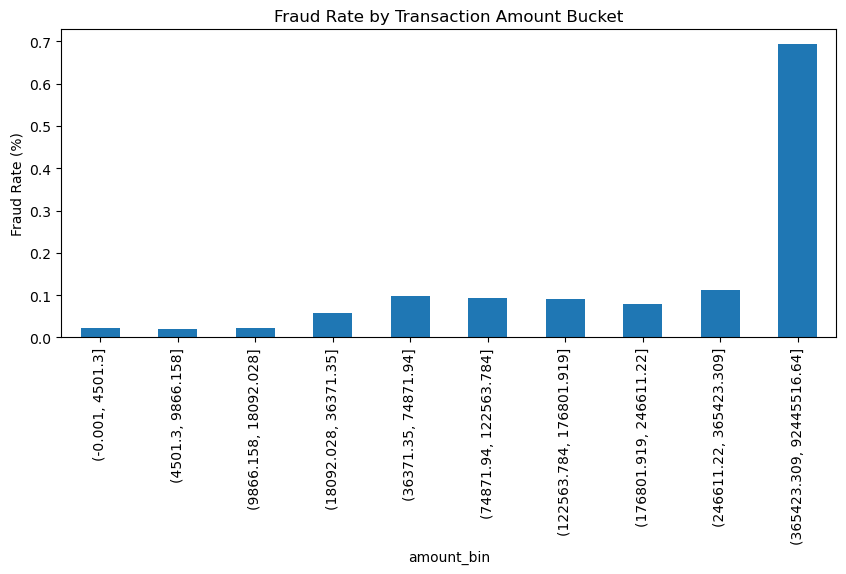

In [109]:
#Fraud Rate by amount bucket
df['amount_bin']=pd.qcut(df['amount'],10,duplicates='drop')

fraud_rate=df.groupby('amount_bin')['isFraud'].mean()
fraud_rate=fraud_rate * 100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud Rate (%)")
plt.title('Fraud Rate by Transaction Amount Bucket')
plt.show()


This analysis demonstrates fraud rate increases significantly in higher value transcation amount buckets. Higher value transaction should receive stricter monitoring...

In [110]:
#Checking missing values

df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64

In [111]:
#Checking merchant transactions (destination starting with 'M')---payments made to business rather than individual
merchant_transactions=df[df['nameDest'].str.startswith('M')]

#if yu want to view selecte columns
#merchant_transactions=df[df['nameDest'].str.startswith('M')][['type','amount','nameOrig','nameDest']]

#Summary statistics--all values are zero, 0's are structural
merchant_transactions[['oldbalanceDest','newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


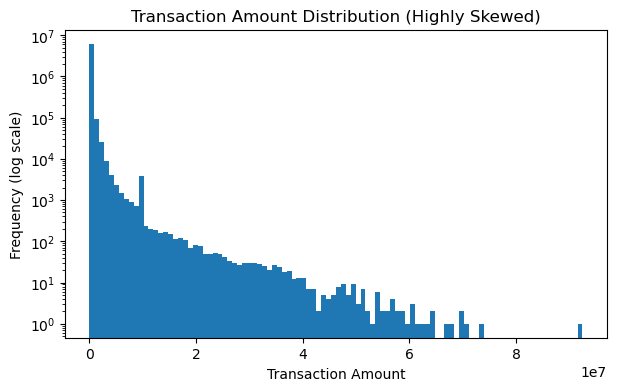

In [112]:
#Outlier Handling
df['amount'].describe()

#Summary stats--observe max and min transaction, data is highly skewed.
#To visualize skewness, plotting a histogram

plt.figure(figsize=(7,4))

#plotting a granular view how transaction values are spread as there are too many samll & high value transactions--
# and smaller transaction dominates the chart
plt.hist(df['amount'], bins=100)

#changing the y-axis to a logarithmic scale as there are many small transactions + very few large ones and data is highly skewed
#Log scale = (1, 10, 100, 1000…)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Transaction Amount Distribution (Highly Skewed)')
plt.show()

From this visualization, it can be observed a right tail, that means small number of transaction involve high amount

But here removing outliers means removing fraud itself


In [113]:
#Handling skewness 
#Log transform (since the data is right skewed) to reduce skewness
#Log transformation shrinks big numbers and stretches small numbers so the data becomes more balanced. It replaces each data point x
#with log x---Transforamtion helps to create a better ML model, specially for regression models

#log1p instead of log because log1p uses (x+1). If there's 0 then log 0 becomes mathematically undefined.

df['log_amount']=np.log1p(df['amount'])

#Flagging the transactions above 99th percentile, for separating very large transactions

p99=df['amount'].quantile(0.99)
df['is_high_amount']=(df['amount']>p99).astype(int)
df['is_high_amount'].value_counts()

#quantile : Give me the value such that 99% of transactions are below it
#.astype(int) : converts the True/False values into 1/0. df['amount']>p99 returns boolean values.
# 0's --> the values <= 99th percentile
# 1's --> the values > 99th precentile


is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

is_high_amount tells that the top 1% transaction amounts capturing extreme value behaviour strongly assocaited with fraudulent activities


In [114]:
#Overview
total_transactions=len(df)
fraud_transactions=df['isFraud'].sum()
fraud_rate = fraud_transactions / total_transactions
fraud_percentage = fraud_rate*100
flagged_percentage=(df['isFlaggedFraud'].sum()/total_transactions)*100

#Total no. of transactions in the dataset
print(f"Total transactions: {total_transactions:,}")

#Total no. of fraud transactions (isFraud=1)
print(f"Fraud transactions: {fraud_transactions:,}")

#Fraud Rate
print(f"Overall Fraud Rate: {fraud_rate:.4%}")

#Converting fraud rate into %
print(f"Fraudulent transactions(isFraud=1): {fraud_percentage:.4f}%")

#
print(f"Flagged fraudulent transactions(isFlaggedFraud=1): {flagged_percentage:.4f}%")



Total transactions: 6,362,620
Fraud transactions: 8,213
Overall Fraud Rate: 0.1291%
Fraudulent transactions(isFraud=1): 0.1291%
Flagged fraudulent transactions(isFlaggedFraud=1): 0.0003%


From these metrics, we can see around 0.13% truly fraudulent transactions are undetected. The existing system cannot tell the approximate number if fraudulent ransactions motivating the need of a good ML model

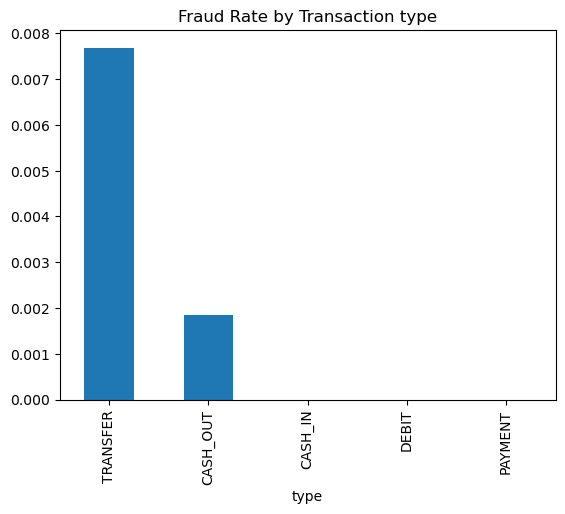

In [115]:
#Grouping the fraudulent transactions by payment type

#using mean since it gives average transaction amount for each transaction type
grouped=df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Fraud Rate by Transaction type")
plt.show()

In [116]:

#Time-based overview

#steps in the dataset represents time in squential order. COnverting steps into hourly day format (0-23)

df['hour']=df['step'] % 24
df['hour'].value_counts().to_frame()

,count
hour,
19,647814
18,580509
20,553728
12,483418
13,468474
11,445992
16,441612
17,439941
14,439653


In [117]:
#Aggregate hourly stats
#total_transactions in hour 0 means total transactions at midnight (00:00)
#using sum to find fraud transactions because 1+1+1+1........gives the total fraudulent transactions

hourly_stats= (
    df.groupby('hour')
    .agg(
        total_transactions= ('isFraud', 'count'),
        fraud_transactions= ('isFraud', 'sum'),
        fraud_rate= ('isFraud', 'mean')
    )
    .reset_index()
)
display(hourly_stats)

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790
5,5,1641,366,0.223035
6,6,3420,358,0.104678
7,7,8988,328,0.036493
8,8,26915,368,0.013673
9,9,283518,341,0.001203


In [118]:
#A check if the no. of fraud transactions match

hourly_stats['fraud_transactions'].sum()==df['isFraud'].sum()

np.True_

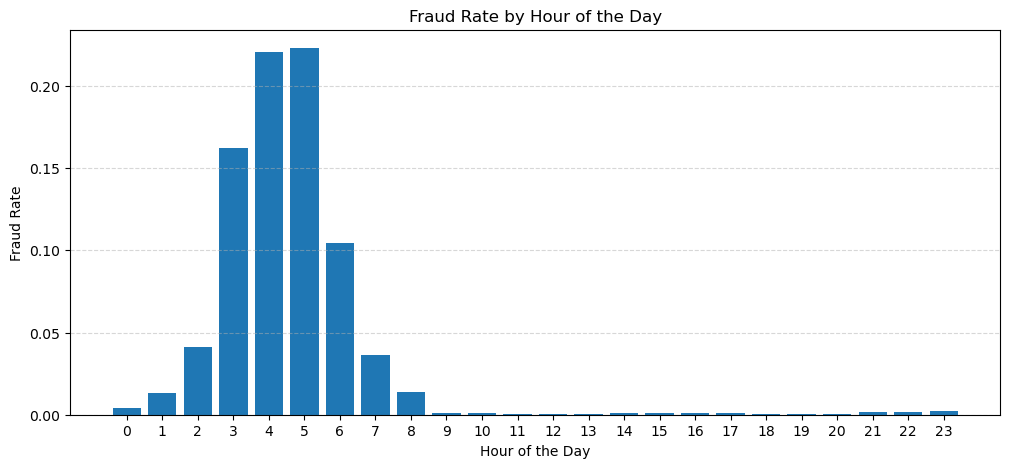

In [119]:
#Visualizing hourly fraud transactions through a bar chart

plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'],hourly_stats['fraud_rate'])
plt.xlabel('Hour of the Day')

#set the label marks on x axis. Here from 0 to 23
plt.xticks(range(0,24))
plt.grid(axis='y' , linestyle='--', alpha=0.5)
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.show()

This analysis demonstrate fraudulent spikes are greater at late night/early morning in 2-8 am window

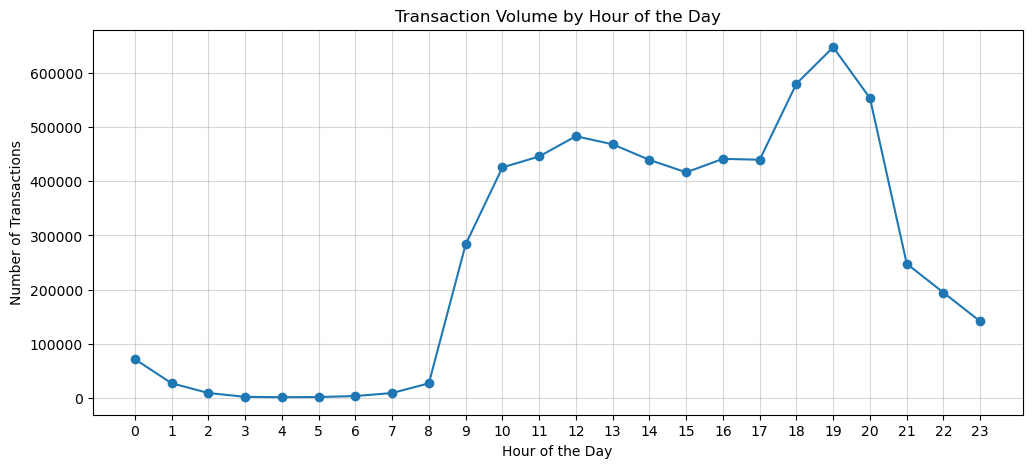

In [120]:
#Visualizing transaction volumn by hour of the day

plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.ylabel('Number of Transactions')
plt.xlabel('Hour of the Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.title('Transaction Volume by Hour of the Day')
plt.show()


This tells the total transaction rate at each hour of the day & high fraud rate during low value hour signifies targetted attacks...

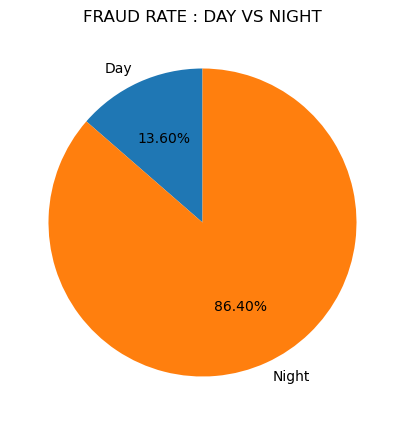

In [121]:
# Day vs Night Fraud Rate Comparison

plt.figure(figsize=(20,5))

#Selecting the hours we want
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

#Within the selected hours, picking the fraudulent transactions (isFraud=1)....
#applying mean to get the average fraud rate in those hours
day_night_fraud = (
    df.groupby('is_night')['isFraud']
    .mean()  
    .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=90,
)

plt.ylabel('')
plt.title('FRAUD RATE : DAY VS NIGHT')
plt.show()


Represantation of late night low supervision window. 

Text(0.5, 1.0, 'CORRELATION HEATMAP OF TRANSACTION FEATURES')

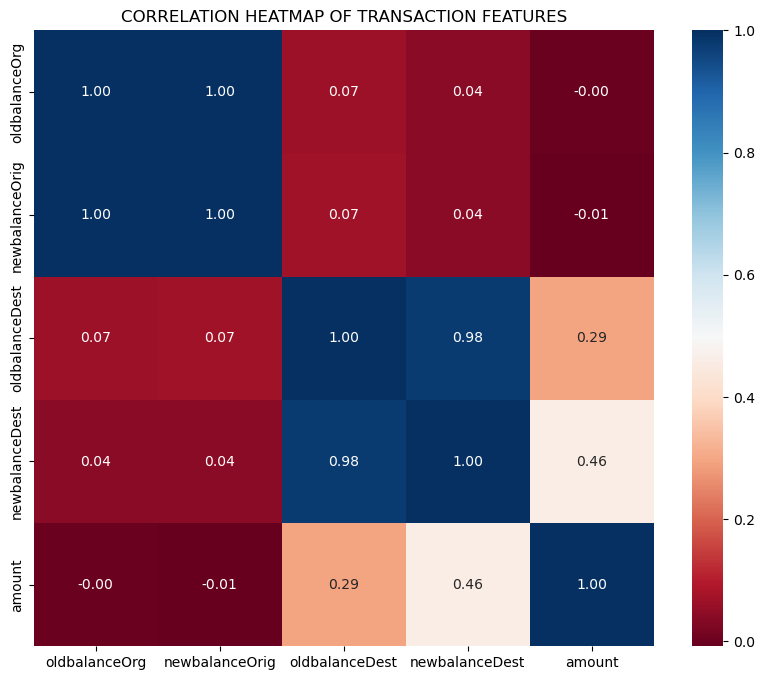

In [122]:
#Finding correlation to check the dependency of these columns
#
import seaborn as sns

plt.figure(figsize=(10,8))
corr = df[['oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest','amount']].corr()

sns.heatmap(corr, annot=True,  cmap='RdBu', fmt='.2f')
plt.title('CORRELATION HEATMAP OF TRANSACTION FEATURES')


This correlation matrix reveals severe multicollinearlity between pre and post transactrion balances, indicating redundancy. To address this balance, different features and redundant variables need to be removed, improving model stability and interpreyability.

FEATURE ENGINEERING AND DATA CLEANING

In [123]:
#Raw transactional data is transformed into meaningful signals from which models learn

#Feature Engineering - Balance differences

#balance reduced from sender's account....instead of giving 2 values, we can only use the transaction impact
df['balance_difference_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

#now for the receiver...calculating how much balance is added to destination account
df['balance_difference_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


In [124]:
#Feature Reduction (no longer need the original balance columns)
df = df.drop(columns=['oldbalanceOrg',  'newbalanceOrig', 'newbalanceDest', 'oldbalanceDest'])

In [125]:
df.drop(columns=['amount_bin'], inplace=True)

In [126]:
df.fillna(0, inplace=True)

In [127]:
df.drop(['nameOrig','nameDest'], axis=1, inplace=True)
df

,step,type,amount,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_difference_orig,balance_difference_dest
0,1,PAYMENT,9839.64,0,0,9.194276,0,1,1,9839.64,0.00
1,1,PAYMENT,1864.28,0,0,7.531166,0,1,1,1864.28,0.00
2,1,TRANSFER,181.00,1,0,5.204007,0,1,1,181.00,0.00
3,1,CASH_OUT,181.00,1,0,5.204007,0,1,1,181.00,-21182.00
4,1,PAYMENT,11668.14,0,0,9.364703,0,1,1,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,1,0,12.735768,0,23,1,339682.13,339682.13
6362616,743,TRANSFER,6311409.28,1,0,15.657870,1,23,1,6311409.28,0.00
6362617,743,CASH_OUT,6311409.28,1,0,15.657870,1,23,1,6311409.28,6311409.27
6362618,743,TRANSFER,850002.52,1,0,13.652996,0,23,1,850002.52,0.00


Applying Label Encoding to column'type' since there are order of type of transactions

In [128]:
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
 
le=LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
df.drop(['type'], axis=1, inplace=True)



Train Test Split

In [129]:
#Model Training preparation
#separated the input features and target variable.
#x contains predictor variables, removing the labels we trying to predict
#
#test_size ensure 20% is test dataset, 80% is for training
#stratify keeps the same proportion of classes in both train and test sets.
# (for eg: without stratify, Test set might accidentally have 0 fraud cases)
# with stratify, train and test set both maintain 95% non-fraud and 5% fraud cases(for eg)

X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
Y = df['isFraud'].values

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=42)

#RobustScalar over standarscalar because
#StandardScaler → “Let’s center everything using average”
#RobustScaler → “Ignore extreme values, focus on the middle data”

scaler = RobustScaler()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns
scaler.fit(X_train[numerical_cols])

X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

Model Training and Evaluation

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None

import joblib

#Confusion matrix is a simple table used to measure how well a classification model is performing and 
# compares the predictions made by the model with the actual results and shows where the model was right or wrong

#Accuracy: shows how many predictions the model got right out of all the predictions
#Precision: focus on the quality of the model’s positive predictions. It tells us how many of the "positive" predictions were actually correct
#Recall / Sensitivity: measures how good the model is at predicting positives. It shows the proportion of true positives detected out of all the actual positive instances

#AUC-ROC curve is a graph used to check how well a binary classification model works. It helps us to understand how well the model separates 
# the positive cases like people with a disease from the negative cases like people without the disease at different threshold level
#AUC : Area under curve (measures the area under the ROC curve. A higher AUC value indicates better model performance as it suggests a greater 
#      ability to distinguish between classes. An AUC value of 1.0 indicates perfect performance while 0.5 suggests it is random guessing.) 
#ROC : Receiver Operating Characteric (plots TPR vs FPR ) 

#Specificity: measures the proportion of actual negatives that the model correctly identifies. It is calculated as 1 - FPR

#Unlike the ROC curve which looks at both positives and negatives the PR curve focuses only on how well the model handles the positive class. 
# This makes it useful when the goal is to detect important cases like fraud, diseases or spam messages.



In [131]:
#import sys
#!{sys.executable} -m pip install xgboost

In [132]:
models={}

#Logistic Regression

print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3,
    n_jobs=-1
)
lr.fit(X_train, Y_train)
models['LogisticRegression'] = lr
print('Logistic Regression trained')

# max_iter : Default is usually 100, Increasing to 300 helps the model finish learning properly (More iterations = more time to converge)
# n_jobs : parallel processing , trains fast as it uses all cpu cores.
# class_weight='balanced' automatically gives importance to minority classes (fraud)


# Random Forest 

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42 
)
rf.fit(X_train, Y_train)
models['RandomForest'] = rf
print("Random Forest trained")

# n_estimators=50 : no. of trees in random forest reduced for faster training
# n_jobs : parallel processing , trains fast as it uses all cpu cores.
# min_samples_leaf=100 avoid deep splits in nodes of trees

# XGBoost

if xgb is not None:
    print("Training XGBoost...")
    
    #class imbalance rate
    scale_pos = (Y_train==0).sum() / (Y_train==1).sum()
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=50,
        scale_pos_weight=(Y_train==0).sum() / (Y_train==1).sum(),
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
        
        
        
    )
xgb_model.fit(X_train, Y_train)
models['XGBoost'] = xgb_model
print("XGBoost trained")

# scale_pos calculates the imbalance rate between fraud and non-fraud,. Fraud class gets more importance
# n_estimators = Number of trees the model builds.
# learning_rate=0.1 = How fast model learns
# 


Training Logistic Regression...
Logistic Regression trained
Training Random Forest...
Random Forest trained
Training XGBoost...
XGBoost trained


Evaluation Metrics

In [133]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve, average_precision_score

results=[]
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
        
    print('\n', name)
    print(classification_report(Y_test,(scores>0.5).astype(int)))
    results.append({'model':name, 'roc_auc': roc_auc_score(Y_test,scores), 'auprc': average_precision_score(Y_test,scores)})

pd.DataFrame(results).sort_values('auprc', ascending=False)

# models dictionary contain the trained ML models and its hyperparamters
# results = Store final scores of each model.

#hasattr(model, 'predict_proba'): checks if the model has an attribute 'predict_proba'. 
#predict_proba = returns the probability estimates for each class

# [:,1] = all rows, but column index 1 (Column 1 = probability of label 1 (fraud))
# (scores > 0.5).astype(int) = convers values less than 0.5 to 0(non fraud) and valuesgreater than 0.5 to fraud (1)
# classification_report(Y_test,(scores>0.5).astype(int)) = compares actual labels vs predicted labels

# predict_proba() → gives probabilities (0 to 1 usually)
# decision_function() → gives raw confidence scores (can be negative or positive, not probabilities)
#                       (negative = likely not fraud, posyive = likely fraud)


        


 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 RandomForest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.05      0.97      0.10      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.54   1272524
weighted avg       1.00      0.98      0.99   1272524


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.97      0.99   1270881
           1       0.05      0.98      0.09      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.98      0.54   1272524
weighted avg       1.00     

,model,roc_auc,auprc
2,XGBoost,0.998221,0.862925
1,RandomForest,0.997763,0.832866
0,LogisticRegression,0.977494,0.550412


In fraud detection, recall is usually prioritized because missing fraudulent transactions is more costly than investigating false positives.
Missed fraud can cause real damage like stolen money, customer complaints, trust damage, etc etc

Higher AUC = The model effectively distinguishes between positive and negative instances.

In spite of all the models acheiving high ROC-AUC score, PR-AUC reveals that XGBoost significantly outperforms other models in identifying rare fraud cases, making it the best candidate for deployment in an imbalanced fraud detection setting

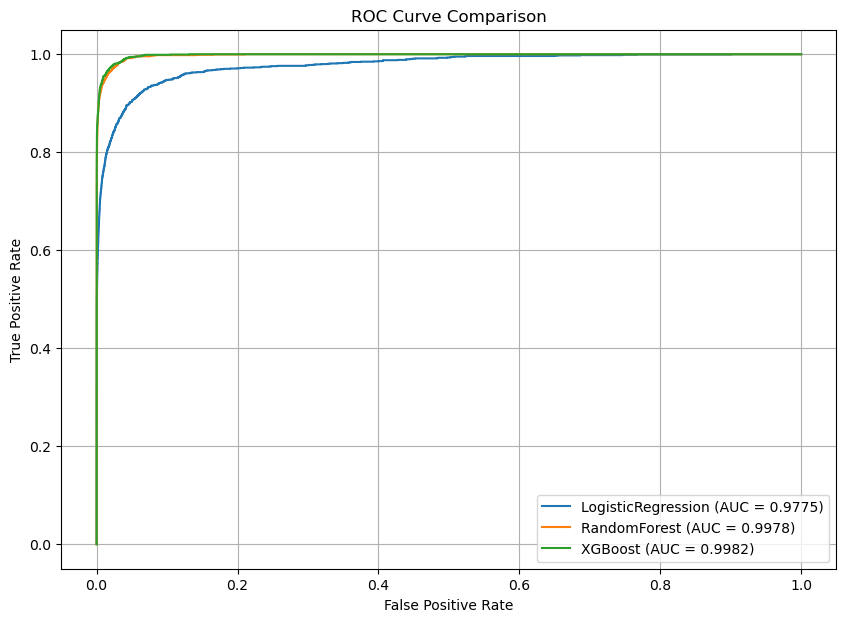

In [134]:
# Why ROC curve is needed?
# helps to find the optimal threshold value that maximizes recall while minimizing precision (based on the ask)

#ROC - Receiver Operating Characteristic . A curve created by plotting TPR vs FPR at different threshold and helps to distinguish the
# positve and negative classes.

# AUC - Area under the curve quantifies the overall performaceof the classifier by calculating the area under the ROC curve
#       Higher AUC = The model effectively distinguishes between positive and negative instances

# average precision score : metric that summarizes precision-recall curve into a single value representing the weighted mean of
#                           precision achieved at different thresold.

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10,7))

for name, model in models.items():
    
    # Get probability scores
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    
    # ROC values
    fpr, tpr, thresholds = roc_curve(Y_test, scores)
    auc_score = roc_auc_score(Y_test, scores)
    
    # Plot each model
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

Tuning the Decision Thresold 

In [135]:
from sklearn.metrics import precision_recall_curve

#Choosing the best model 
model = models['XGBoost']

#Getting the fraud probabilities
Y_scores = model.predict_proba(X_test)[:,1]

#Genenrating precision,recall and thresholds...for each thresholds, calculates precision & recall
precision, recall, thresholds = precision_recall_curve(Y_test, Y_scores)

# Find threshold where recall>=90% and choose highest precision

# There are N thresholds, but N + 1 precision/recall points because the curve includes an extra endpoint 
# representing the classifier behavior beyond the listed thresholds.
candidates= [ 
            (t,p,r) for t,p,r in zip(thresholds, precision[:-1], recall[:-1])
            if r >= 0.90
            ]

best_threshold, best_precision, best_recall = max(candidates, key=lambda x: x[1])
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Precision: {best_precision:.3f} || Recall: {best_recall:.3f}")

Y_pred = (Y_scores >= best_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

# Print detailed confusion matrix
print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual Legit (0)", "Actual Fraud (1)"],
    columns=["Predicted Legit (0)", "Predicted Fraud (1)"]
))

print("\nDetailed Breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print(f"\nFraud recall: {tp/(tp+fn):.3f}")
print(f"Fraud Precision: {tp/(tp+fp):.3f}")




Best Threshold: 0.9074
Precision: 0.286 || Recall: 0.900

Confusion Matrix:
                  Predicted Legit (0)  Predicted Fraud (1)
Actual Legit (0)              1267196                 3685
Actual Fraud (1)                  164                 1479

Detailed Breakdown:
True Negatives (TN): 1267196
False Positives (FP): 3685
False Negatives (FN): 164
True Positives (TP): 1479

Fraud recall: 0.900
Fraud Precision: 0.286


After threshold optimization, the model flags transactions only when fraud probability exceeds 0.9096 (0.91 approx). This achieves ~90% fraud recall while improving precision to ~33% significantly reducing false positives and operational review costs.

Q1) Why is highest precision needed?
In fraud detection, once a strong recall target is achieved, the next focus is maximizing precision because precision measures how many transactions flagged as fraud are actually fraudulent. Higher precision is important because it reduces false positives, meaning fewer legitimate customer transactions are incorrectly blocked or sent for review. This improves customer experience, lowers operational workload for fraud analysts, and reduces unnecessary investigation costs. For example, if two thresholds both catch 90% of fraud cases, but one has 25% precision and the other has 60% precision, the second threshold is far better because it generates cleaner and more reliable fraud alerts. Therefore, after ensuring most fraud is detected, highest precision is needed to make the system efficient and practical for real-world use.

Q2) Why does recall fall when threshold increases?
Recall falls when the threshold increases because the model becomes more strict in classifying a transaction as fraud. A higher threshold means only transactions with very high fraud probabilities are flagged, while many moderately suspicious fraud cases are ignored. As a result, the number of true frauds detected decreases and missed fraud cases increase, causing recall to drop. For example, if the threshold is 0.30, the model may catch most fraud transactions, but if it is increased to 0.80, only the most obvious fraud cases are detected while smaller or less certain frauds are missed. This creates the natural tradeoff where higher thresholds often improve precision but reduce recall. Therefore, selecting the right threshold is essential to balance fraud detection performance.

Fine Tuning the model

In [136]:
#Optimizing the hyperparameters of XGBoost
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=scale_pos,
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, Y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [137]:
rf_tuned = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
    
)

rf_tuned.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=100, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [138]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
    
)

lr_tuned.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

Evaulating the scores of each model after optimization

In [139]:
def evaluate(model, X, Y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(Y, scores),
        "PR-AUC": average_precision_score(Y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, Y_test))
print("RF:", evaluate(rf_tuned, X_test, Y_test))
print("LR:", evaluate(lr_tuned, X_test, Y_test))

XGB: {'ROC-AUC': np.float64(0.9980840288006573), 'PR-AUC': np.float64(0.8740805698558138)}
RF: {'ROC-AUC': np.float64(0.9976349903964784), 'PR-AUC': np.float64(0.8413888709444023)}
LR: {'ROC-AUC': np.float64(0.9775241671352014), 'PR-AUC': np.float64(0.5505615614911855)}


After fine tuning all the models with revised metrics, RF : very close to XGBoost but slightly weaker in fraud precision recall balance, but perfroms excellent. LR: significantly lower PR-AUC meaning it struggles to separate real fraud cases from normal transactions since linear models cannot capture complex fraud patterns. PR-AUC is the most realistic metric since fraud detection is highly imbalanced.

XGBoost is the best performing model as it catches most frauds with fewer false alarms (FP) making it operationally efficient for fraud investigation teams.

Saving the fne-tuned model

In [140]:
models={
    "LogisticRegression": lr_tuned,
    "RandomForest":  rf_tuned,
    "XGBoost": xgb_tuned
}

#This code picks the best model based on the highest AUPRC score from a list called results, 
# then retrieves the actual model object from models.

best_model_name = max(results, key=lambda x: x['auprc'])["model"]
best_model = models[best_model_name]

best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: XGBoost
 Decision threshold: 0.9074


In [141]:
#Loading the saved model


artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact['model']
threshold = artifact['threshold']
features = artifact['features']

#Prediction on test data

#The model predicts the probability that each test row belongs to class 1 (positive class).
Y_scores_new = model.predict_proba(X_test[features])[:, 1]
Y_pred_new = (Y_scores_new >= threshold).astype(int)

#COnfusion Matrix
cm_new = confusion_matrix(Y_test, Y_pred_new)
tn1, fp1, fn1, tp1 = cm_new.ravel()

#Summary table
summary = pd.DataFrame({
    "Count": [tp1, fn1, fp1, tn1]
}, index=[
    "Correctly predicted fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correctly predicted non-fraud (TN)"
])

print(summary)

# Calculating recall and precision
print(f"\nFraud recall: {tp1/(tp1+fn1):.3f}")
print(f"Fraud Precision: {tp1/(tp1+fp1):.3f}")



                                      Count
Correctly predicted fraud (TP)         1479
Missed fraud (FN)                       164
False alarms (FP)                      3076
Correctly predicted non-fraud (TN)  1267805

Fraud recall: 0.900
Fraud Precision: 0.325


Improved the model from 29% precision to 33% which reduces the rate of false alarms lowering operational costs and improving customer trust. At the same time, the model catches fraud with greater efficiency.

* Built a Fraud Detection System using Machine Learning on large-scale highly imbalanced transaction data (6M+) to identify suspicious financial activities and reduce fraud risk.
* Utilized ML models like Logistic Regression, Random Forest, and XGBoost models to identify and predict fraud patterns using ROC-AUC score and PR-AUC, summarizing XGBoost as the top performer for rare-event fraud detection.
* Optimized fraud alert decision threshold to achieve ~90% fraud detection rate while improving precision from ~29% to ~33%, significantly reducing false alarms and lowering manual investigation workload.
* Performed fraud behavior analytics that uncovered higher fraud concentration in high-value transactions and late-night hours, enabling stronger risk-monitoring strategies.
* Packaged the best-performing tuned model into a reusable production artifact (.pkl) with saved features and threshold for scalable real-time fraud scoring.